In [1]:
import pandas as pd
import numpy as np

In [2]:
from Bio import SeqIO
def read_fasta(file_path):
    names = []
    sequences = []
    for record in SeqIO.parse(file_path, "fasta"):
        names.append(record.id)
        sequences.append(str(record.seq))
    return names, sequences

In [3]:
file_path = 'uniprotkb_Tenebrio_molitor_2025_06_04.fasta'
names, sequences = read_fasta(file_path)

In [4]:
len(names)==len(sequences)

True

In [5]:
data_df = pd.DataFrame(np.array([names,sequences]).T,columns=["Protein accession","sequence"])
data_df.head(3)

,Protein accession,sequence
0,tr|A0A141AZQ3|A0A141AZQ3_TENMO,MQQFVAGLKSRSADVRQKTARELSLYVKSELREATADEITSFLDEF...
1,tr|A0A8J6H106|A0A8J6H106_TENMO,MDASQPHPRSDEPDFEYSRWLSSAPPGEEVVISGMSGRLPDSRNIH...
2,tr|A0A8J6HB08|A0A8J6HB08_TENMO,MGLTSNAAYKHAVPQAPDIHNVMNPDVYKGPWGGAHCRDSPVQTTR...


In [6]:
data_df.shape

(49131, 2)

In [32]:
# Arg-C proteinase
# the R amino acid was retained by the N terminal amino acid
def Arg_C(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if seq[i]=='R':
                cleavage.append(i)
    return cleavage

# ASP-D
# the D amino acid was retanied by the C terminal peptides
def Asp_D(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if seq[i+1]=='D':
                cleavage.append(i)
    return cleavage

# Asp-N Endopeptidase + N-terminal Glu:
# the D and E amino acid was retanied by the C terminal peptides
# Asp(D) or Glu(E) in position P1'
def Asp_N(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if seq[i+1]=='D' or seq[i+1] == 'E':
                cleavage.append(i)
    return cleavage

# BNPs endopeptidase
def BNPs(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if seq[i]=='W':
                cleavage.append(i)
    return cleavage

#Caspase 1
def Caspase1(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-4:
            if seq[i]=='F'or seq[i] == 'W'or seq[i] == 'Y'or seq[i] == 'L':
                if seq[i+2]=='H'or seq[i+2] == 'A'or seq[i+2] == 'T':
                    if seq[i+3]=='D':
                        if seq[i+4]!='P'or seq[i+4]!='E'or seq[i+4]!='D'or seq[i+4]!='Q'or seq[i+4]!='K'or seq[i+4]!='R':
                            cleavage.append(i+3)
    return cleavage


#Caspase 2
def Caspase2(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-4:
            if seq[i]=='D':
                if seq[i+1]=='V':
                    if seq[i+2]=='A':
                        if seq[i+3]=='D':
                            if seq[i+4]!='P'or seq[i+4]!='E'or seq[i+4]!='D'or seq[i+4]!='Q'or seq[i+4]!='K'or seq[i+4]!='R':
                                cleavage.append(i+3)
    return cleavage
#Caspase 3
def Caspase3(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-4:
            if seq[i]=='D':
                if seq[i+1]=='M':
                    if seq[i+2]=='Q':
                        if seq[i+3]=='D':
                            if seq[i+4]!='P'or seq[i+4]!='E'or seq[i+4]!='D'or seq[i+4]!='Q'or seq[i+4]!='K'or seq[i+4]!='R':
                                cleavage.append(i+3)
    return cleavage
#Caspase 4
def Caspase4(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-4:
            if seq[i]=='L' :
                if seq[i+1]=='E':
                    if seq[i+2]=='V':
                        if seq[i+3]=='D':
                            if seq[i+4]!='P'or seq[i+4]!='E'or seq[i+4]!='D'or seq[i+4]!='Q'or seq[i+4]!='K'or seq[i+4]!='R':
                                cleavage.append(i+3)
    return cleavage
#Caspase 5
def Caspase5(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-3:
            if seq[i]=='L' or seq[i]== 'W'  :
                if seq[i+1]=='E':
                    if seq[i+2]=='H':
                        if seq[i+3]=='D':
                            cleavage.append(i+3)
    return cleavage
#Caspase 6
def Caspase6(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-4:
            if seq[i]=='V' :
                if seq[i+1]=='E':
                    if seq[i+2]=='H'or seq[i]== 'I'  :
                        if seq[i+3]=='D':
                            if seq[i+4]!='P'or seq[i+4]!='E'or seq[i+4]!='D'or seq[i+4]!='Q'or seq[i+4]!='K'or seq[i+4]!='R':
                                cleavage.append(i+3)
    return cleavage
#Caspase 7
def Caspase7(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-4:
            if seq[i]=='D' :
                if seq[i+1]=='E':
                    if seq[i+2]=='V'  :
                        if seq[i+3]=='D':
                            if seq[i+4]!='P'or seq[i+4]!='E'or seq[i+4]!='D'or seq[i+4]!='Q'or seq[i+4]!='K'or seq[i+4]!='R':
                                cleavage.append(i+3)
    return cleavage
#Caspase 8
def Caspase8(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-4:
            if seq[i]=='I' or seq[i]=='L':
                if seq[i+1]=='E':
                    if seq[i+2]=='T':
                        if seq[i+3]=='D':
                            if seq[i+4]!='P'or seq[i+4]!='E'or seq[i+4]!='D'or seq[i+4]!='Q'or seq[i+4]!='K'or seq[i+4]!='R':
                                cleavage.append(i+3)
    return cleavage
#Caspase 9
def Caspase9(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-3:
            if seq[i]=='L' :
                if seq[i+1]=='E':
                    if seq[i+2]=='H':
                        if seq[i+3]=='D':
                            cleavage.append(i+3)
    return cleavage
#Caspase 10
def Caspase10(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-3:
            if seq[i]=='I' :
                if seq[i+1]=='E':
                    if seq[i+2]=='A':
                        if seq[i+3]=='D':
                            cleavage.append(i+3)
    return cleavage


#Chymotrypsin-high specificity(C-term to [FYW], not before P)
def chymo_high(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if seq[i]=='F' or seq[i] == 'Y':
                if seq[i+1] != 'P':
                    cleavage.append(i)
            if seq[i]=='W' :
                if seq[i+1] != 'P' and seq[i] != 'M':
                    cleavage.append(i)
    return cleavage

#Chymotrypsin-low specificity (C-term to [FYWML], not before P)
def chymo_low(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if seq[i]=='F' or seq[i] == 'L' or seq[i] == 'Y':
                if seq[i+1] != 'P':
                    cleavage.append(i)
            if seq[i]=='W' :
                if seq[i+1] != 'P' and seq[i] != 'M':
                    cleavage.append(i)
            if seq[i]=='M' :
                if seq[i+1] != 'P' and seq[i] != 'Y':
                    cleavage.append(i)
            if seq[i]=='H' :
                if seq[i+1] != 'D' and seq[i] != 'M' and seq[i] != 'P' and seq[i] != 'W':
                    cleavage.append(i)
    return cleavage


#Clostripain (Clostridiopeptidase B)
def Clostripain(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if seq[i]=='R':
                cleavage.append(i)
    return cleavage
#CNBr
def CNBr(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if seq[i]=='M':
                cleavage.append(i)
    return cleavage
#Enterokinase
def Enterokinase(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-3:
            if seq[i]=='D' or seq[i]== 'E':
                if seq[i+1]=='D' or seq[i+1]== 'E':
                    if seq[i+2]=='D' or seq[i+2]== 'E':
                        if seq[i+3]=='K':
                            cleavage.append(i+3)
    return cleavage

#Factor_xa
#A,F,G,I,L,T,V or M
def Factor_xa(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-3:
            if seq[i]=='A' or seq[i]== 'F'or seq[i]== 'G'or seq[i]== 'I'or seq[i]== 'L'or seq[i]== 'T'or seq[i]== 'V'or seq[i]== 'M':
                if seq[i+1]=='D' or seq[i+1]== 'E':
                    if seq[i+2]=='G':
                        if seq[i+3]=='R':
                            cleavage.append(i+3)
    return cleavage
#Formic_acid
def Formic_acid(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if seq[i]=='D':
                cleavage.append(i)
    return cleavage
#Glutamyl_endopeptidase
def Glutamyl_endopeptidase(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if seq[i]=='E':
                cleavage.append(i)
    return cleavage
#GranzymeB
def GranzymeB(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-3:
            if seq[i]=='I':
                if seq[i+1]== 'E':
                    if seq[i+2]=='P':
                        if seq[i+3]=='D':
                            cleavage.append(i+3)
    return cleavage
#Hydroxylamine
def Hydroxylamine(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if seq[i]=='N' and seq[i+1] == 'G':
                cleavage.append(i)
    return cleavage
#Iodosobenzoic_acid
def Iodosobenzoic_acid(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if seq[i]=='W':
                cleavage.append(i)
    return cleavage
#LysC
def LysC(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if seq[i]=='K':
                cleavage.append(i)
    return cleavage
#Neutrophil_elastase
def Neutrophil_elastase(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if seq[i]=='A' or seq[i]== 'V':
                cleavage.append(i)
    return cleavage
#NTCB (2-nitro-5-thiocyanobenzoic acid)
def NTCB(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if seq[i+1]=='C':
                cleavage.append(i)
    return cleavage
#Pepsin (pH1.3)
def Pepsin_1(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if seq[i+1]== 'L' or seq[i+1]== 'F':
                cleavage.append(i)
                if i>=2 and i<seq_len-1:
                    if seq[i-1]=='P'or seq[i-2] == 'H' or  seq[i-2] == 'K' or  seq[i-2] == 'R' or seq[i-2]=='P':
                        cleavage.remove(i)
                if i ==1:
                    if seq[i-1]=='P':
                        cleavage.remove(i)
                if i==seq_len-1:
                    if seq[i-1]=='R':
                        cleavage.remove(i)

            if seq[i]== 'L' or seq[i]== 'F':
                if i not in cleavage: # when meet ASLLAL the double L will cause the repeat postion extraction
                    cleavage.append(i)
                if i>=2 and i<seq_len-1:
                    if seq[i-1]=='P'or seq[i-2] == 'H' or  seq[i-2] == 'K' or  seq[i-2] == 'R' or seq[i-2]=='P':
                        cleavage.remove(i)
                if i ==1:
                    if seq[i-1]=='P':
                        cleavage.remove(i)
                if i==seq_len-1:
                    if seq[i-1]=='R':
                        cleavage.remove(i)
                if i ==seq_len:
                    if seq[i]== 'L' or seq[i]== 'F':
                        cleavage.remove(i)

    return cleavage


#Pepsin (pH>2)
def Pepsin_2(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if seq[i+1]== 'L' or seq[i+1]== 'F' or seq[i+1]== 'Y' or seq[i+1]== 'W':
                cleavage.append(i)
                if i>=2 and i<seq_len-1:
                    if seq[i-1]=='P'or seq[i-2] == 'H' or  seq[i-2] == 'K' or  seq[i-2] == 'R' or seq[i-2]=='P':
                        cleavage.remove(i)
                if i ==1:
                    if seq[i-1]=='P':
                        cleavage.remove(i)
                if i==seq_len-1:
                    if seq[i-1]=='R':
                        cleavage.remove(i)
            if seq[i]== 'L' or seq[i]== 'F'or seq[i]== 'Y' or seq[i]== 'W':
                if i not in cleavage: # when meet ASLLAL the double L will cause the repeat postion extraction
                    cleavage.append(i)
                if i>=2 and i<seq_len-1:
                    if seq[i-1]=='P'or seq[i-2] == 'H' or  seq[i-2] == 'K' or  seq[i-2] == 'R' or seq[i-2]=='P':
                        cleavage.remove(i)
                if i ==1:
                    if seq[i-1]=='P':
                        cleavage.remove(i)
                if i==seq_len-1:
                    if seq[i-1]=='R':
                        cleavage.remove(i)
                if i ==seq_len:
                    if seq[i]== 'L' or seq[i]== 'F'or seq[i]== 'Y' or seq[i]== 'W':
                        cleavage.append(i)

    return cleavage
#Proline_endopeptidase
def Proline_endopeptidase(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-2:
            if seq[i]=='H' and seq[i]== 'K'and seq[i]== 'R':
                if seq[i+1]=='P' :
                    if seq[i+2]!='P':
                        cleavage.append(i+1)
    return cleavage
#Proteinase_K
#A,E,F,I,L,T,V,W or Y
def Proteinase_K(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if seq[i]=='A' or seq[i]== 'E' or seq[i]== 'F'or seq[i]== 'I'or seq[i]== 'L'or seq[i]== 'T'or seq[i]== 'V'or seq[i]== 'W'or seq[i]== 'Y':
                cleavage.append(i)
    return cleavage
#Staphylococcal_peptidase_I
def Staphylococcal_peptidase_I(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if i==0:
                if seq[i]== 'E':
                    cleavage.append(i)
            if seq[i]!='E':
                if seq[i+1]== 'E':
                    cleavage.append(i+1)
    return cleavage

#Thermolysin
def Thermolysin(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if seq[i]!='E'and seq[i]!= 'D':
                if seq[i+1]== 'A' or seq[i+1] == 'F'or seq[i+1] == 'I'or seq[i+1] == 'L'or seq[i+1] == 'M'or seq[i+1] == 'V':
                    cleavage.append(i)
    return cleavage
#Thrombin
def Thrombin(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-2:
            if seq[i]=='G':
                if seq[i+1] == 'R':
                    if seq[i+2] =='G':
                        cleavage.append(i+1)
        if i < seq_len-4:
            if seq[i]== 'A' or seq[i] == 'F'or seq[i] == 'G'or seq[i] == 'I'or seq[i] == 'L'or seq[i] == 'T'or seq[i] == 'V' or seq[i] == 'M':
                if seq[i+1]== 'A' or seq[i+1] == 'F'or seq[i+1] == 'G' or seq[i+1] == 'I'or seq[i+1] == 'L'or seq[i+1] == 'T'or seq[i+1] == 'V' or seq[i+1] == 'W':
                    if seq[i+2]=='P':
                        if seq[i+3]=='R':
                            if seq[i+4]!='D' and seq[i+4] != 'E':
                                cleavage.append(i+3)
                            if i+5 == seq_len-1:# position index is from 0 instead of 1
                                if seq[i+5]=='D' and seq[i+5] == 'E':
                                    cleavage.remove(i+3)
    return cleavage
#Trypsin (please note the exceptions!)
def Trypsin(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if seq[i]=='K' or seq[i] =='R':
                if seq[i+1] != 'P':
                    cleavage.append(i)
        if i < seq_len-2:
            if seq[i] == 'W':
                if seq[i+1] == 'K':
                    if seq[i+2] =='P':
                        cleavage.append(i+1)
        if i < seq_len-2:
            if seq[i] =='M':
                if seq[i+1] == 'R':
                    if seq[i+2] =='P':
                        cleavage.append(i+1)
        if i < seq_len-2:
            if seq[i] =='E':
                if seq[i+1] == 'R':
                    if seq[i+2] =='P':
                        cleavage.append(i+1)
        #situation will block the cleavage
        if i < seq_len-2:
            if seq[i]=='D' or seq[i]=='C':
                if seq[i+1] == 'K':
                    if seq[i+2] == 'D':
                        if i+1 in cleavage:
                            cleavage.remove(i+1)
        if i < seq_len-2:
            if seq[i]=='C':
                if seq[i+1] == 'K':
                    if seq[i+2] == 'H' or seq[i+2] == 'Y':
                        if i+1 in cleavage:
                            cleavage.remove(i+1)
        if i < seq_len-2:
            if seq[i]=='C':
                if seq[i+1] == 'R':
                    if seq[i+2] == 'K':
                        if i+1 in cleavage:
                            cleavage.remove(i+1)
        if i < seq_len-2:
            if seq[i]=='R':
                if seq[i+1] == 'R':
                    if seq[i+2] == 'H' or seq[i+2] =='R':
                        if i+1 in cleavage:
                            cleavage.remove(i+1)
    return cleavage


# only pepsin and trypsin are following the cleavage cites data from PeptideCutter
# obtanined from http://hazralab.iitr.ac.in/new-documentation-01.html
# Elastase_1
def Elastase_1(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if seq[i]=='A':
                cleavage.append(i)
    return cleavage

# Elastase_2 (Neutrophil_elastase)
def Elastase_2(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if seq[i]=='A' or seq[i]=='V':
                cleavage.append(i)
    return cleavage

# chymotrypsinogen_B1
def chymotrypsinogen_B1(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if seq[i]=='F' or seq[i]=='L'or seq[i]=='W'or seq[i]=='Y':
                cleavage.append(i)
    return cleavage
# chymotrypsinogen_C
def chymotrypsinogen_C(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if seq[i]=='F' or seq[i]=='M' or seq[i]=='L'or seq[i]=='W'or seq[i]=='Y' or seq[i]=='N'or seq[i]=='Q':
                cleavage.append(i)
    return cleavage

# pancreatic_enteropeptidase_E
def pancreatic_enteropeptidase_E(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if seq[i]=='A':
                cleavage.append(i)
    return cleavage

# Enteropeptidase   ///this protein need to take the p1' into consideration
def Enteropeptidase(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if seq[i]=='K' and seq[i+1] =='I':
                cleavage.append(i)
    return cleavage
# prostasin  ///highly specificity
def prostasin(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-7:
            if seq[i]=='R':
                if seq[i+1]=='K':
                    if seq[i+2]=='R':
                        if seq[i+3]=='K':
                            if seq[i+4]=='I':
                                if seq[i+5]=='S':
                                    if seq[i+6]=='G':
                                        if seq[i+7]=='K':
                                            cleavage.append(i+3)
    return cleavage

#Gastricsin
def Gastricsin(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if seq[i]=='Y':
                cleavage.append(i)
    return cleavage

# Fruit_Bromelain
def Fruit_Bromelain(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-2:
            if seq[i]=='F':
                if seq[i+1]=='V':
                    if seq[i+2]=='R':
                        cleavage.append(i+2)
    return cleavage
#Stem_Bromelain
def Stem_Bromelain(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if seq[i]=='R':
                if seq[i+1]=='R':
                    cleavage.append(i+1)
    return cleavage
# Ananain
def Ananain(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-2:
            if seq[i]=='F':
                if seq[i+1]=='V':
                    if seq[i+2]=='R':
                        cleavage.append(i+2)
    return cleavage
# Papaya_proteinase
def Papaya_proteinase(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if seq[i]=='G':
                cleavage.append(i)
    return cleavage

# Chymopapain
def Chymopapain(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if seq[i]== 'A' or seq[i] == 'V'or seq[i] == 'L'or seq[i] == 'I'or seq[i] == 'F'or seq[i] == 'W':
                if seq[i+1] == 'R' or seq[i+1] == 'L':
                    cleavage.append(i+1)
    return cleavage

# Chymosin
def Chymosin(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if seq[i]=='S' or seq[i]=='F':
                if seq[i+1]=='M'or seq[i]=='A':
                    cleavage.append(i)
    return cleavage

#Caricain
#same to the chymopapain
def Caricain(seq,seq_len):
    cleavage=[]
    for i in range(seq_len):
        if i < seq_len-1:
            if seq[i]== 'A' or seq[i] == 'V'or seq[i] == 'L'or seq[i] == 'I'or seq[i] == 'F'or seq[i] == 'Y' or seq[i] == 'W':
                if seq[i+1] == 'R' or seq[i+1] == 'L':
                    cleavage.append(i+1)
    return cleavage

In [33]:
data_df.shape

(49131, 2)

In [34]:
import collections
import os
from tqdm import tqdm

In [35]:
#全部
#options= [Arg_C,Asp_D,Asp_N,BNPs,Caspase1,Caspase2,Caspase3,Caspase4,Caspase5,Caspase6,Caspase7,Caspase8,Caspase9,Caspase10,chymo_high,chymo_low,Clostripain,CNBr,Enterokinase,Factor_xa,Formic_acid,Glutamyl_endopeptidase,GranzymeB,Hydroxylamine,Iodosobenzoic_acid,LysC,Neutrophil_elastase,NTCB,Pepsin_1,Pepsin_2,Proline_endopeptidase,Proteinase_K,Staphylococcal_peptidase_I,Thermolysin,Thrombin,Trypsin,Elastase_1,Elastase_2, chymotrypsinogen_B1, chymotrypsinogen_C, pancreatic_enteropeptidase_E, Enteropeptidase,prostasin,Gastricsin,Fruit_Bromelain,Stem_Bromelain,Ananain,Papaya_proteinase,Chymopapain,Chymosin, Caricain]
# assign the function name to option_names for further file generating
#options_names= ['Arg_C','Asp_D','Asp_N','BNPs','Caspase1','Caspase2','Caspase3','Caspase4','Caspase5','Caspase6','Caspase7','Caspase8','Caspase9','Caspase10','chymo_high','chymo_low','Clostripain','CNBr','Enterokinase','Factor_xa','Formic_acid','Glutamyl_endopeptidase','GranzymeB','Hydroxylamine','Iodosobenzoic_acid','LysC','Neutrophil_elastase','NTCB','Pepsin_1','Pepsin_2','Proline_endopeptidase','Proteinase_K','Staphylococcal_peptidase_I','Thermolysin','Thrombin','Trypsin','Elastase_1','Elastase_2', 'chymotrypsinogen_B1', 'chymotrypsinogen_C', 'pancreatic_enteropeptidase_E', 'Enteropeptidase','prostasin','Gastricsin','Fruit_Bromelain','Stem_Bromelain','Ananain','Papaya_proteinase','Chymopapain','Chymosin', 'Caricain']


In [36]:
options= [chymo_high,chymo_low,Pepsin_1,Pepsin_2,Trypsin]
# assign the function name to option_names for further file generating
options_names= ['chymo_high','chymo_low','Pepsin_1','Pepsin_2','Trypsin']


In [37]:
seq = data_df.sequence #sequence info

In [38]:
seq_num=[len(i) for i in seq]

In [39]:
seq.shape

(49131,)

# 开始酶切

In [40]:
len(options)

5

In [55]:
data_base = {}
for k in tqdm(range(len(options))):
    E_1 = options[k]
    all_pep_seqs = []
    for j in tqdm(range(len(seq))):
        sequen=seq[j]
        seq_len=len(seq[j])
        one_cleavage = []
        one_pep_seq=[]
        one_cleavage = E_1(sequen,seq_len)
        one_cleavage.insert(0,0)
        one_cleavage.insert(len(one_cleavage),seq_len-1)# only to make it easy w  
        for i in range(len(one_cleavage)-1):
            if i == 0:
                pep_seq_temp = sequen[one_cleavage[i]:one_cleavage[i+1]+1]
                if len(pep_seq_temp) > 5 and len(pep_seq_temp) < 25: 
                    one_pep_seq.append(pep_seq_temp)
            else:
                pep_seq_temp = sequen[one_cleavage[i]+1:one_cleavage[i+1]+1]
                if len(pep_seq_temp) > 5 and len(pep_seq_temp) < 25:     
                    one_pep_seq.append(pep_seq_temp)
        if len(one_pep_seq)!=0:
            all_pep_seqs.append(one_pep_seq)
    merged_list = [item for sublist in all_pep_seqs for item in sublist]
    unique_list = list(set(merged_list))
    data_base[options_names[k]] = unique_list

  4%|█▋                                         | 1987/49131 [00:01<00:27, 1703.41it/s]


 67%|████████████████████████████              | 32760/49131 [00:10<00:03, 5012.68it/s]


 16%|██████▊                                    | 7725/49131 [00:06<00:24, 1682.58it/s]


 61%|█████████████████████████▍                | 29760/49131 [00:16<00:05, 3705.89it/s]


  5%|██▎                                         | 2632/49131 [00:04<01:31, 509.10it/s]


...

 58%|████████████████████████▎                 | 28417/49131 [00:24<00:08, 2579.31it/s]


  1%|▎                                            | 387/49131 [00:00<01:33, 519.21it/s]


 24%|█████████▉                                | 11672/49131 [00:10<00:26, 1404.77it/s]


 58%|████████████████████████▌                 | 28740/49131 [00:20<00:07, 2630.48it/s]


100%|████████████████████████████████████████████████████| 5/5 [01:48<00:00, 21.68s/it]


# 所以的酶定向分析

In [56]:
"""
import pandas as pd
from collections import Counter

# 假设 data_base 是如下结构的字典：
# data_base = {
#     'chymo_high': ['AAACCC', 'AAACCC', 'GGGTTT'],
#     'chymo_low': ['AAA', 'AAT', 'AAA'],
#     'Pepsin_1': [...],
#     ...
# }

def analyze_database(data_base):
    summary = []

    for enzyme, sequences in data_base.items():
        # 去重
        unique_seqs = list(set(sequences))
        count = len(unique_seqs)

        # 统计长度分布
        lengths = [len(seq) for seq in unique_seqs]
        length_distribution = dict(Counter(lengths))

        summary.append({
            'Enzyme': enzyme,
            'Unique Count': count,
            'Length Distribution': length_distribution
        })

    return pd.DataFrame(summary)

# 示例调用
# result_df = analyze_database(data_base)
# print(result_df)

# 若需要展开每个长度分布为列（更直观分析）：
def expanded_length_distribution(data_base):
    all_lengths = set()
    dist_records = []

    for enzyme, sequences in data_base.items():
        unique_seqs = set(sequences)
        length_counter = Counter([len(seq) for seq in unique_seqs])
        all_lengths.update(length_counter.keys())

        entry = {'Enzyme': enzyme, 'Unique Count': len(unique_seqs)}
        entry.update(length_counter)
        dist_records.append(entry)

    df = pd.DataFrame(dist_records)
    df = df.fillna(0).astype({l: int for l in all_lengths if isinstance(l, int)})
    return df.sort_values('Enzyme')

# 若你要输出到 Excel 或 CSV：
expanded_length_distribution(data_base).to_csv("summary.csv", index=False)
"""

'\nimport pandas as pd\nfrom collections import Counter\n\n# 假设 data_base 是如下结构的字典：\n# data_base = {\n#     \'chymo_high\': [\'AAACCC\', \'AAACCC\', \'GGGTTT\'],\n#     \'chymo_low\': [\'AAA\', \'AAT\', \'AAA\'],\n#     \'Pepsin_1\': [...],\n#     ...\n# }\n\ndef analyze_database(data_base):\n    summary = []\n\n    for enzyme, sequences in data_base.items():\n        # 去重\n        unique_seqs = list(set(sequences))\n        count = len(unique_seqs)\n\n        # 统计长度分布\n        lengths = [len(seq) for seq in unique_seqs]\n        length_distribution = dict(Counter(lengths))\n\n        summary.append({\n            \'Enzyme\': enzyme,\n            \'Unique Count\': count,\n            \'Length Distribution\': length_distribution\n        })\n\n    return pd.DataFrame(summary)\n\n# 示例调用\n# result_df = analyze_database(data_base)\n# print(result_df)\n\n# 若需要展开每个长度分布为列（更直观分析）：\ndef expanded_length_distribution(data_base):\n    all_lengths = set()\n    dist_records = []\n\n    for enzyme, s

In [58]:
from collections import Counter

# 合并并去重
chymo = list(set(data_base['chymo_high'] + data_base['chymo_low']))
pepsin = list(set(data_base['Pepsin_1'] + data_base['Pepsin_2']))
trypsin = list(set(data_base['Trypsin']))

# 定义统计函数
def get_stats(peptides):
    lengths = [len(p) for p in peptides]
    count = len(peptides)
    length_distribution = dict(Counter(lengths))
    total = sum(length_distribution.values())
    length_percentage = {k: f"{v / total:.2%}" for k, v in length_distribution.items()}
    return {
        "Unique Count": count,
        "Length Distribution": length_distribution,
        "Length Percentage": length_percentage
    }

# 统计结果
result = {
    'chymo': get_stats(chymo),
    'pepsin': get_stats(pepsin),
    'trypsin': get_stats(trypsin)
}

# 打印结果（按长度升序显示）
for enzyme, stats in result.items():
    print(f"\n{enzyme.upper()}")
    print(f"Unique Sequences Count: {stats['Unique Count']}")
    print("Length\tCount\tPercentage")
    for length in sorted(stats['Length Distribution']):
        count = stats['Length Distribution'][length]
        perc = stats['Length Percentage'][length]
        print(f"{length}\t{count}\t{perc}")


CHYMO
Unique Sequences Count: 1590329
Length	Count	Percentage
6	229917	14.46%
7	220036	13.84%
8	178961	11.25%
9	145157	9.13%
10	125902	7.92%
11	108167	6.80%
12	89918	5.65%
13	76670	4.82%
14	67480	4.24%
15	57930	3.64%
16	49886	3.14%
17	44787	2.82%
18	38797	2.44%
19	33756	2.12%
20	30480	1.92%
21	26759	1.68%
22	23811	1.50%
23	21516	1.35%
24	20399	1.28%

PEPSIN
Unique Sequences Count: 1286027
Length	Count	Percentage
6	181487	14.11%
7	161562	12.56%
8	137412	10.69%
9	119750	9.31%
10	103725	8.07%
11	89475	6.96%
12	77639	6.04%
13	67016	5.21%
14	58081	4.52%
15	51208	3.98%
16	43848	3.41%
17	37875	2.95%
18	32338	2.51%
19	28233	2.20%
20	24500	1.91%
21	21734	1.69%
22	18624	1.45%
23	16843	1.31%
24	14677	1.14%

TRYPSIN
Unique Sequences Count: 906333
Length	Count	Percentage
6	111002	12.25%
7	104922	11.58%
8	91954	10.15%
9	79204	8.74%
10	70593	7.79%
11	62172	6.86%
12	54114	5.97%
13	48804	5.38%
14	43084	4.75%
15	37298	4.12%
16	33928	3.74%
17	30182	3.33%
18	26788	2.96%
19	23761	2.62%
20	21607	2.38%
21	1

In [59]:
df_new_sequence = pd.DataFrame({key: pd.Series(value) for key, value in data_base.items()})

In [60]:
for key, value in data_base.items():
    df = pd.DataFrame({key: value})
    df.to_csv(f'{key}.csv', index=False)
print("CSV 文件保存完成！")

CSV 文件保存完成！


In [61]:
all_values = list(set(val for sublist in data_base.values() for val in sublist))

In [62]:
len(all_values)

3658466

In [63]:
filtered_values = [value for value in all_values if str(value).strip() != '' and not pd.isna(value)]

In [64]:
len(filtered_values)

3658466

In [65]:
with open('output.txt', 'w') as f:
    f.write("Peptide\n")
    for value in filtered_values:
        f.write(f"{value}\n")

print("TXT 文件保存完成！")

TXT 文件保存完成！


In [66]:
len_filtered_values = [len(i) for i in filtered_values]

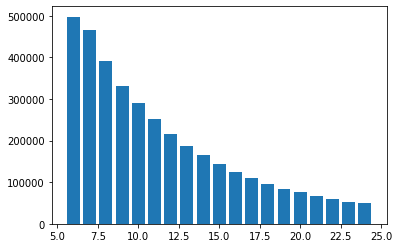

In [67]:
import matplotlib.pyplot as plt
# 计算每个数字的数量
value_counts = {}
for value in len_filtered_values:
    value_counts[value] = value_counts.get(value, 0) + 1
# 提取数字和计数
values = list(value_counts.keys())
counts = list(value_counts.values())
plt.bar(values, counts)
plt.show()

In [68]:
df_values = pd.DataFrame(np.array([values,counts]).T,columns=["values","counts"])
df_values.to_csv("统计.csv",index=None)

# 扇形图

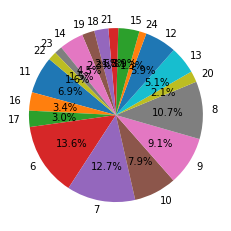

In [69]:
# 计算每个数字的数量
value_counts = {}
total_values = len(len_filtered_values)
for value in len_filtered_values:
    value_counts[value] = value_counts.get(value, 0) + 1
# 计算每个数字的概率
value_probabilities = {key: value / total_values for key, value in value_counts.items()}
# 绘制扇形图
labels = value_probabilities.keys()
sizes = value_probabilities.values()
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
#plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
#plt.title('数字概率分布')
plt.show()

In [70]:
length_df=pd.DataFrame(np.array([filtered_values,len_filtered_values]).T, columns=["peptide","length"])

In [71]:
length_df['length'] = length_df['length'].astype(int)

In [73]:
#挑选
len_filtered_df = length_df[(length_df['length'] >= 6) & (length_df['length'] <= 24)]

In [74]:
len_filtered_df.shape

(3658466, 2)

In [75]:
len_filtered_df.to_csv("6-24.csv",index=None)

In [81]:
import pandas as pd

# 1. 读取TXT文件（假设为制表符分隔的文本）

df = pd.read_csv("6-24.csv")

# 2. 提取并去重多肽序列
if 'peptide' not in df.columns:
    raise ValueError("文件中未包含 'Peptide' 列，请检查文件格式。")

peptides = df['peptide'].dropna().unique()  # 去除缺失值并去重

# 3. 写入FASTA文件
output_file = "converted_output.fas"
with open(output_file, 'w') as f:
    for i, seq in enumerate(peptides, 1):
        f.write(f">peptide_{i}\n{seq}\n")

print(f"已成功生成 FASTA 文件：{output_file}")

已成功生成 FASTA 文件：converted_output.fas


### 使用CD-HIT进行去除冗余，-c为0.75

## 加载数据

#### 清除非标准氨基酸

In [90]:
from Bio import SeqIO

# 1. 设置输入输出文件名
input_file = "seq-out-xiaohua.fasta"
output_file = "seq-out-xiaohua.cleaned.fasta"

# 2. 标准氨基酸集合（大写单字母）
valid_amino_acids = set("ARNDCQEGHILKMFPSTWYV")

# 3. 过滤并写入新FASTA
with open(output_file, "w") as out_f:
    for record in SeqIO.parse(input_file, "fasta"):
        sequence = str(record.seq).upper()
        if all(residue in valid_amino_acids for residue in sequence):
            SeqIO.write(record, out_f, "fasta")

print(f"清洗完成，合法序列已保存至: {output_file}")


清洗完成，合法序列已保存至: seq-out-xiaohua.cleaned.fasta


In [91]:
file_path1 = 'seq-out-xiaohua.cleaned.fasta'
names1, sequences1 = read_fasta(file_path1)

In [92]:
data_df_CD = pd.DataFrame(np.array([names1,sequences1]).T,columns=["peptide_name","peptide"])
data_df_CD.head(3)

,peptide_name,peptide
0,peptide_2,ECSELLQQELDELEQK
1,peptide_3,RAKNGARSADEAINTVH
2,peptide_20,QIAAAPPGGAREGSCHWSRTNSVN


In [93]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from Bio import SeqIO
from tqdm import tqdm

In [94]:
sequences=list(data_df_CD["peptide"].values)

In [95]:
# 定义氨基酸分类
hydrophobic_aa = {'A', 'I', 'L', 'M', 'F', 'P', 'W', 'V'}
positive_aa = {'K', 'R'}
negative_aa = {'D', 'E'}


sequence_ok = []
count_aas=[]
percent_aas=[]
molecular_weights=[]
aromaticitys=[]
flexibilitys=[]
isoelectric_points=[]
secondary_structure_fractions=[]
gravys=[]
instability_indexs=[]
hydrophobic_counts=[]
charges = []
for i in tqdm(range(0,len(sequences))):
    protein_sequence = sequences[i]
    if "X" not in protein_sequence or "U" not in protein_sequence:
        sequence_ok.append(protein_sequence)
        prot_param = ProteinAnalysis(protein_sequence)
        #count_aa = prot_param.count_amino_acids()
        #percent_aa = prot_param.get_amino_acids_percent()
        molecular_weight = prot_param.molecular_weight()
        aromaticity = prot_param.aromaticity()
        #flexibility = prot_param.flexibility()
        isoelectric_point = prot_param.isoelectric_point()
        secondary_structure_fraction = prot_param.secondary_structure_fraction()
        gravy = prot_param.gravy()
        #instability_index = prot_param.instability_index()
        #count_aas.append(count_aa)
        #percent_aas.append(percent_aa)
        molecular_weights.append(molecular_weight)
        aromaticitys.append(aromaticity)
        #flexibilitys.append(flexibility)
        isoelectric_points.append(isoelectric_point)
        secondary_structure_fractions.append(secondary_structure_fraction)
        gravys.append(gravy)
        #instability_indexs.append(instability_index)

        total_length = len(protein_sequence)  # 多肽总长度
        hydrophobic_count = sum(1 for aa in protein_sequence if aa in hydrophobic_aa)  # 疏水性氨基酸数量
        #positive_count = sum(1 for aa in protein_sequence if aa in positive_aa)  # 带正电氨基酸数量
        #negative_count = sum(1 for aa in protein_sequence if aa in negative_aa)  # 带负电氨基酸数量
        #charge=positive_count-negative_count
        charge = prot_param.charge_at_pH(7)
    # 计算疏水性氨基酸占比
        hydrophobic_ratio = hydrophobic_count / total_length if total_length > 0 else 0
        hydrophobic_counts.append(hydrophobic_ratio)
        charges.append(charge)

100%|████████████████████████████████████████| 821054/821054 [01:31<00:00, 8993.88it/s]


In [96]:
ok_dft = pd.DataFrame(np.array([sequence_ok,molecular_weights,isoelectric_points,aromaticitys,gravys,hydrophobic_counts,charges,secondary_structure_fractions]).T,
                     columns=["peptide","mw","PI","aromaticitys","gravys","hydrophobic_ratio","charges","ss"])

D:\BaiduNetdiskDownload\Anaconda\envs\rdkit\lib\site-packages\ipykernel_launcher.py:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  """Entry point for launching an IPython kernel.


In [97]:
#电荷大于等于2
charge_df_ok = ok_dft[ok_dft["charges"]>=2]
charge_df_ok.shape

(82304, 8)

In [98]:
sorted_df = charge_df_ok.sort_values(by='gravys', ascending=False)

In [99]:
sorted_df.to_csv("Rsorted_df_ok.csv",index=None)

# 上述用于抗菌肽筛选

In [115]:
result.keys()

dict_keys(['chymo', 'pepsin', 'trypsin'])

In [126]:
list_name="trypsin"
length_distribution=result[list_name]["Length Distribution"]

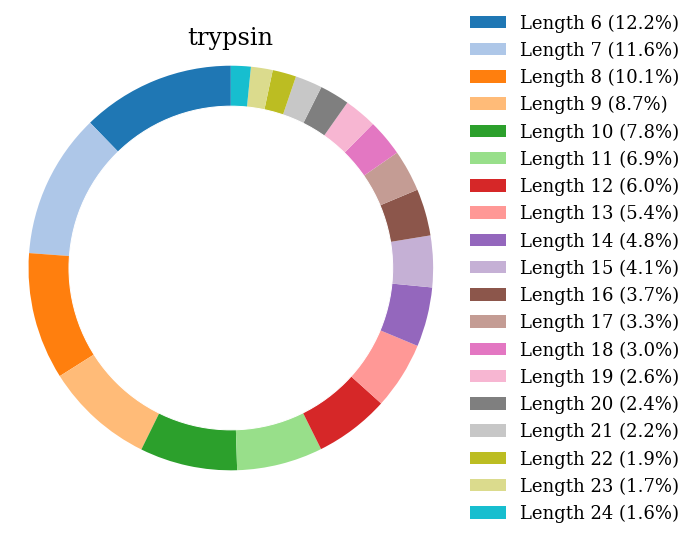

In [127]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
# 排序处理（按键升序）
# 按长度从小到大排序
length_distribution = dict(sorted(length_distribution.items()))

# 标签与数据
labels = [f'Length {k}' for k in length_distribution.keys()]
sizes = list(length_distribution.values())

new_df = pd.DataFrame({"Peptide size": labels, 'total_content': sizes})
total_count=sum(sizes)
class_counts = new_df["total_content"]/ total_count
new_df["class_counts"]=class_counts

new_df_ok = new_df.sort_values(by='total_content', ascending=False)
new_df_ok.set_index("Peptide size", inplace=True)
class_counts=new_df_ok["class_counts"]

plt.figure(figsize=(8, 8))
plt.pie(class_counts, labels=[''] * len(class_counts), startangle=90, colors=plt.cm.tab20.colors)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.axis('off')  # Hide all text in the plot

# 绘制环形图
my_circle=plt.Circle( (0,0), 0.8, color='white')
# 获得当前显示的图表，也就是前面画的饼图
p=plt.gcf()
# 将两图相加
p.gca().add_artist(my_circle)

# 添加图例
legend_labels = [f'{class_name} ({prob*100:.1f}%)' for class_name, prob in zip(class_counts.index, class_counts)]

# 设置图例的字体属性
prop = fm.FontProperties(family='serif', size=18)  # 使用新罗马字体，字体大小为14
plt.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0.5), prop=prop,frameon=False)

title_font = {'family': 'serif', 'size': 24}  # 使用新罗马字体，字体大小为20
plt.title(list_name, fontdict=title_font)
plt.savefig(f"{list_name}_含量.png",dpi=300,bbox_inches='tight')
plt.show()

In [113]:
labels

['长度 6',
 '长度 7',
 '长度 8',
 '长度 9',
 '长度 10',
 '长度 11',
 '长度 12',
 '长度 13',
 '长度 14',
 '长度 15',
 '长度 16',
 '长度 17',
 '长度 18',
 '长度 19',
 '长度 20',
 '长度 21',
 '长度 22',
 '长度 23',
 '长度 24']